In [7]:
import numpy as np
import matplotlib.pyplot as plt


В цьому домашньому завданні ми реалізуємо логістичну регресію на `numpy`.
Ці завдання допоможуть вам ґрунтовно засвоїти основні концепції логістичної регресії та реалізувати їх на практиці 🔥

#### Завдання 1: Реалізація функції сигмоїди
1. З використанням `numpy` напишіть функцію `sigmoid(z)` для обчислення значення сигмоїди згідно з формулою:
   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$
2. Використовуючи цю функцію, обчисліть значення сигмоїди для наступних даних: $ z = [-2, -1, 0, 1, 2] $. Виведіть результат обчислень.


In [29]:
def sigmoid(z):
  sigma = (1 + np.exp(-z))**-1
  return sigma

In [30]:
z = np.linspace(-2,2,5)
print(z)

[-2. -1.  0.  1.  2.]


In [31]:
sigmoid_data = sigmoid(z)
print(sigmoid_data)

[0.11920292 0.26894142 0.5        0.73105858 0.88079708]


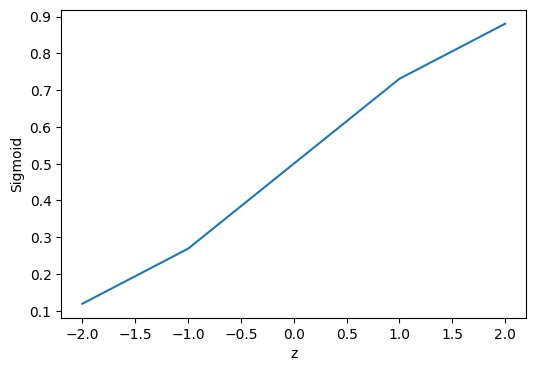

In [32]:
plt.figure(figsize=(6,4))
plt.plot(z, sigmoid_data)
plt.xlabel('z')
plt.ylabel('Sigmoid')
plt.show()



#### Завдання 2: Реалізація функції гіпотези для логістичної регресії
1. Напишіть функцію `hypothesis(theta, X)`, яка обчислює гіпотезу для логістичної регресії, використовуючи функцію сигмоїди. Формула гіпотези:
   $$
   h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}
   $$
2. Використайте функцію `hypothesis` для обчислення значень гіпотези для наступних даних:
   
   $\theta = [0.5, -0.5]$
   
   $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  Виведіть результат обчислень.


In [59]:
def hypothesis(theta, X):
  X_T = X.T
  theta_T_X = np.dot(theta, X_T)
  h_x = (1 + np.exp(-theta_T_X))**-1
  return h_x

In [56]:
theta = np.array([0.5, -0.5])
X = np.array([[1,2],[1,-1],[1,0],[1,1]])

In [126]:
X.shape, theta.shape

((4, 2), (2,))

In [62]:
result = hypothesis(theta, X)
print("Отримані значення гіпотези:\n",result)

Отримані значення гіпотези:
 [0.37754067 0.73105858 0.62245933 0.5       ]


#### Завдання 3: Реалізація функції для підрахунку градієнтів фукнції втрат
1. Напишіть функцію `compute_gradient(theta, X, y)`, яка обчислює градієнти функції втрат для логістичної регресії. Формула для обчислення градієнта:
   $$
   \frac{\partial L(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left[ (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)} \right]
   $$
2. Використайте функцію `compute_gradient` для обчислення градієнтів для наступних даних:

  $\theta = [0.5, -0.5]$

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Виведіть результат обчислень.

In [79]:
def compute_gradient(theta, X, y):
  h = hypothesis(theta, X)
  error = h - y
  m = X.shape[0]
  grad = (1/m)*np.dot(X.T, error)
  return grad

In [74]:
theta = np.array([0.5, -0.5])
X = np.array([[1,2],[1,-1],[1,0],[1,1]])
y = np.array([1,0,1,0])

In [80]:
gradient_result = compute_gradient(theta, X, y)

In [98]:
print("Отримані результати градієнтів для коефіцієнтів тета:", gradient_result)

Отримані результати градієнтів для коефіцієнтів тета: [ 0.05776464 -0.36899431]



#### Завдання 4: Реалізація повного батч градієнтного спуску

**Задача:**
1. Напишіть функцію `full_batch_gradient_descent(X, y, lr=0.1, epochs=100)`, яка реалізує алгоритм Full градієнтного спуску для логістичної регресії. Використовуйте такі формули:
   - Гіпотеза: $ h_\theta(x) = \sigma(\theta^T x) $
   - Оновлення параметрів: $ \theta_j := \theta_j - \alpha \frac{\partial L(\theta)}{\partial \theta_j} $
2. Використайте функцію `full_batch_gradient_descent` для обчислення параметрів моделі на наступних даних:

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Увага! Матриця $X$ вже має стовпець одиниць і передбачається, що це. - стовпець для intercept - параметра зсуву.

  Виведіть результат обчислень.


In [99]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
  theta = np.zeros(X.shape[1])
  for i in range(epochs):
    #print(theta)
    gradient_theta = compute_gradient(theta, X, y)
    #print(gradient_theta)
    theta -= lr*gradient_theta
  return theta, gradient_theta


In [96]:
X = np.array([[1,2],[1,-1],[1,0],[1,1]])
y = np.array([1,0,1,0])

In [113]:
theta_final, gradient_theta = full_batch_gradient_descent(X, y)

In [119]:
print("Theta:\n",theta_final, "\nGradient Theta\n", gradient_theta)

Theta:
 [-0.2893693   0.77655125] 
Gradient Theta
 [ 0.02111584 -0.01969352]


#### Завдання 5. Обчислення точності моделі

1. Напишіть функцію `predict_proba(theta, X)`, яка використовує знайдені параметри $\theta$ для обчислення ймовірностей належності поточного прикладу з даних до класу $y=1$ на основі значень $\sigma(\theta^T x)$.

2. Напишіть функцію `predict(theta, X, threshold=0.5)`, яка обчислює клас з передбаченої імовірності належності екземпляра до класу 1 з порогом 0.5. Тобто якщо ймовірність менше 0.5, то передбачаємо клас 0, інакше клас 1.

3. Напишіть функцію `accuracy(y_true, y_pred)`, яка обчислює точність моделі, визначивши частку правильно передбачених класів.

  Формула метрики Accuracy:
  $$
  \text{Accuracy} = \frac{\sum_{i=1}^{m} I(\hat{{y}^{(i)}} = y^{(i)})}{m}
  $$

  де $\hat{{y}^{(i)}}$ - передбачене значення класу, $I$ - індикаторна функція (яка дорівнює 1, якщо умова виконується, і 0 - якщо ні), $m$ - кількість прикладів.

4. Обчисліть з використанням даних в завданні 4 $X$, $y$ та обчислених коефіцієнтах $\theta$ та виведіть на екран:
  - передбачені моделлю імовірності належності кожного з екземплярів в матриці `X` до класу 1
  - класи кожного екземпляра з матриці `X`
  - точність моделі.

In [105]:
def predict_proba(theta, X):
  X_T = X.T
  theta_T_X = np.dot(theta, X_T)
  probability = (1 + np.exp(-theta_T_X))**-1
  return probability

In [109]:
def predict(theta, X, threshold=0.5):
  pred_probability = predict_proba(theta, X)
  classified = (pred_probability >= threshold).astype(int)
  return classified

In [110]:
def accuracy(y_true, y_pred):
  error = y_pred - y_true
  indicator = (error == 0).astype(int)
  accuracy = np.mean(indicator)
  return accuracy

In [121]:
probs = predict_proba(theta_final, X)
print('Передбачені моделлю імовірності належності кожного з екземплярів в матриці X до класу 1:\n', probs)

Передбачені моделлю імовірності належності кожного з екземплярів в матриці X до класу 1:
 [0.77966809 0.25617965 0.42815828 0.61944235]


In [124]:
y_pred = predict(theta_final, X)
print('Класи кожного екземпляра з матриці X:\n', y_pred)
print('\nРеальні значення у:\n', y)

Класи кожного екземпляра з матриці X:
 [1 0 0 1]

Реальні значення у:
 [1 0 1 0]


In [125]:
model_accuracy = accuracy(y, y_pred)
print('Точність моделі\n',model_accuracy)

Точність моделі
 0.5


Можемо бачити, що, за розрахунком, точність моделі 50%. Порівнявши вручну розраховані та реальі значення у бачимо, що дійсно модель розрахувала правильно лише 2/4 значень.